# Concrete Compressive Strength - Linear Regression

## 1. Import Libraries

In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Folder Location

In [2]:
PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data/processed/concrete_data_cleaned.csv").exists()
)
MODEL_FOLDER = PROJECT_ROOT / "models/trained"
REPORT_FOLDER = PROJECT_ROOT / "reports/evaluation/linear_regression"
MODEL_FOLDER.mkdir(parents=True, exist_ok=True)
REPORT_FOLDER.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)

c:\Users\Shankeerthan\Downloads\Concrete-Compressive-Strength-Predictor-Updated\Concrete-Compressive-Strength-Predictor-main


## 3. Load Cleaned Dataset

In [3]:
df = pd.read_csv(PROJECT_ROOT / "data/processed/concrete_data_cleaned.csv")
display(df.head())
print("Dataset shape:", df.shape)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


Dataset shape: (911, 9)


## 4. Feature and Target Separation

In [4]:
target_column = "compressive_strength"
X = df.drop(columns=target_column)
y = df[target_column]
display(X.head())
display(y.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
1,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90
2,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28
4,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28


0    61.89
1    47.03
2    36.45
3    45.85
4    39.29
Name: compressive_strength, dtype: float64

X shape: (911, 8)
y shape: (911,)


## 5. Train-Test Split
80% training, 20% testing; random_state=42.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 728
Testing samples: 183


## 6. Linear Regression Pipeline

In [6]:
linear_pipeline = Pipeline([
    ("selection", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LinearRegression())
])
print(linear_pipeline)

Pipeline(steps=[('selection', VarianceThreshold(threshold=0.01)),
                ('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('model', LinearRegression())])


## 7. Evaluation Function

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    test_predictions = model.predict(X_test)
    train_predictions = model.predict(X_train)
    return {
        "MAE": mean_absolute_error(y_test, test_predictions),
        "MSE": mean_squared_error(y_test, test_predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_predictions)),
        "R²": r2_score(y_test, test_predictions),
        "Train_R²": r2_score(y_train, train_predictions)
    }, test_predictions

## 8. Linear Regression - Baseline Training and Evaluation

In [8]:
linear_results, linear_predictions = evaluate_model(
    linear_pipeline, X_train, X_test, y_train, y_test
)
print(pd.Series(linear_results).round(4))

linear_model = linear_pipeline.named_steps["model"]
coefficients = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(linear_pipeline.named_steps["pca"].n_components_)],
    "Coefficient (scaled inputs)": linear_model.coef_
})
display(coefficients)
print("Intercept:", round(linear_model.intercept_, 4))

MAE          6.0100
MSE         59.7150
RMSE         7.7275
R2           0.7711
Train_R2     0.7068
dtype: float64


,Principal Component,Coefficient (scaled inputs)
0,PC1,-1.638184
1,PC2,-1.208615
2,PC3,5.447771
3,PC4,0.446470
4,PC5,6.434184
5,PC6,9.798658


Intercept: 34.4888


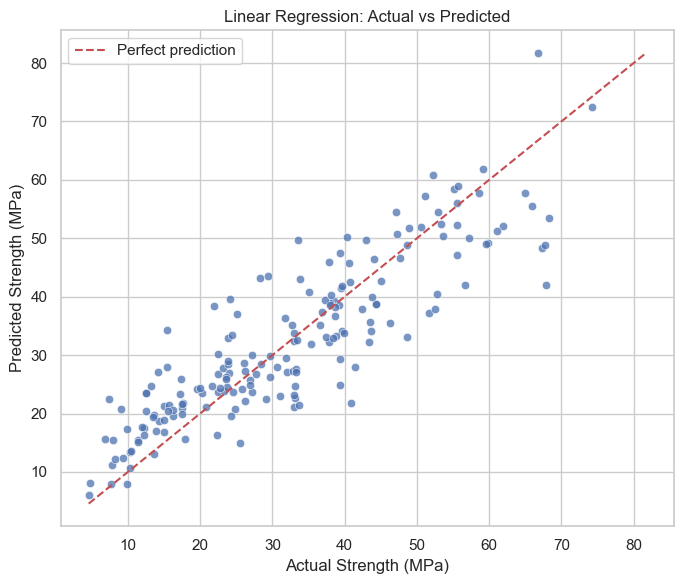

In [9]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=linear_predictions, alpha=0.75)
minimum = min(y_test.min(), linear_predictions.min())
maximum = max(y_test.max(), linear_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum], "r--", label="Perfect prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Five-Fold Cross-Validation

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
negative_mse_scores = cross_val_score(
    linear_pipeline, X_train, y_train,
    cv=cv, scoring="neg_mean_squared_error"
)
fold_rmse = np.sqrt(-negative_mse_scores)
print("Each fold RMSE:", fold_rmse)
print("Mean CV RMSE:", fold_rmse.mean())
print("CV RMSE Standard Deviation:", fold_rmse.std())
pd.DataFrame({"Fold": range(1, 6), "RMSE": fold_rmse}).to_csv(
    REPORT_FOLDER / "baseline_cv_metrics.csv", index=False
)

Each fold RMSE: [7.1272335  8.86742498 8.95949549 8.63534072 9.26052956]
Mean CV RMSE: 8.570004850178083
CV RMSE Standard Deviation: 0.7487114280271544


## 10. Hyperparameter Tuning

In [11]:
linear_parameter_grid = {"model__fit_intercept": [True, False]}
linear_grid_search = GridSearchCV(
    linear_pipeline,
    linear_parameter_grid,
    cv=cv,
    scoring="neg_mean_squared_error"
)
linear_grid_search.fit(X_train, y_train)
print("Best Linear Regression parameters:", linear_grid_search.best_params_)
print("Best Linear Regression CV RMSE:", np.sqrt(-linear_grid_search.best_score_))
best_model = linear_grid_search.best_estimator_

Best Linear Regression parameters: {'model__fit_intercept': True}
Best Linear Regression CV RMSE: 8.602647960630167


## 11. Final Evaluation

In [12]:
final_results, final_predictions = evaluate_model(
    best_model, X_train, X_test, y_train, y_test
)
print(pd.Series(final_results).round(4))
pd.DataFrame([final_results]).to_csv(REPORT_FOLDER / "test_metrics.csv", index=False)

MAE          6.0100
MSE         59.7150
RMSE         7.7275
R2           0.7711
Train_R2     0.7068
dtype: float64


## 12. Actual vs Predicted and Residuals
Residual = Actual − Predicted.

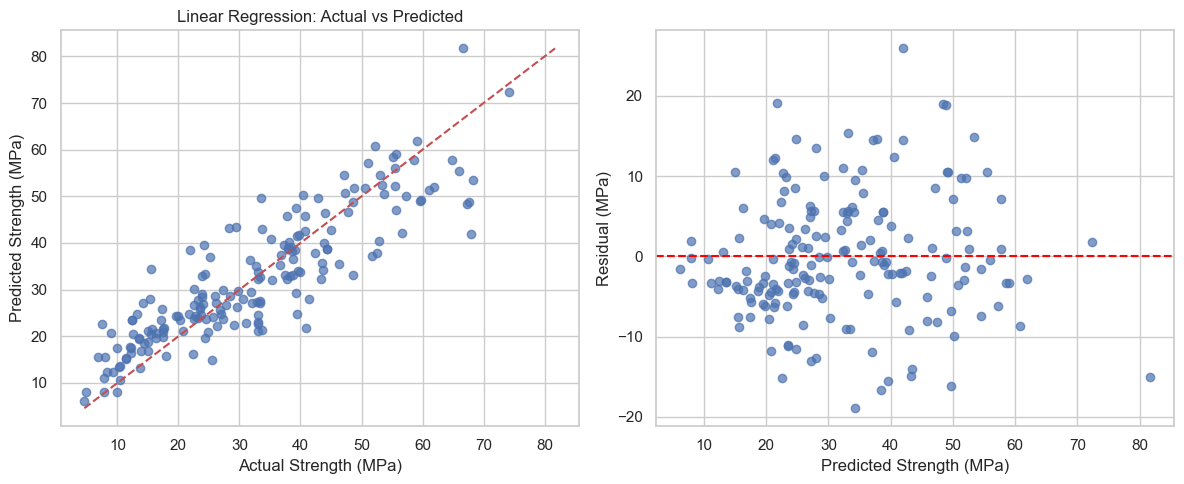

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, final_predictions, alpha=0.7)
minimum = min(y_test.min(), final_predictions.min())
maximum = max(y_test.max(), final_predictions.max())
axes[0].plot([minimum, maximum], [minimum, maximum], "r--")
axes[0].set_xlabel("Actual Strength (MPa)")
axes[0].set_ylabel("Predicted Strength (MPa)")
axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[1].scatter(final_predictions, y_test.to_numpy() - final_predictions, alpha=0.7)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Strength (MPa)")
axes[1].set_ylabel("Residual (MPa)")
plt.tight_layout()
plt.savefig(REPORT_FOLDER / "evaluation_plot.png", dpi=150)
plt.show()

## 13. Final Prediction

In [14]:
# Use one real test observation while preserving the training column order.
sample_input = X_test.iloc[[0]].copy()
sample_prediction = best_model.predict(sample_input)[0]

display(sample_input)
print(f"Predicted Concrete Compressive Strength: {sample_prediction:.2f} MPa")
print(f"Actual strength for this test observation: {y_test.iloc[0]:.2f} MPa")

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
704,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,7


Predicted Concrete Compressive Strength: 37.93 MPa
Actual strength for this test observation: 42.42 MPa


## 14. Save Linear Regression Model

In [15]:
MODEL_PATH = MODEL_FOLDER / "linear_regression_pca_pipeline.joblib"
joblib.dump(best_model, MODEL_PATH, compress=3)
print("Model saved:", MODEL_PATH)

Model saved: c:\Users\Shankeerthan\Downloads\Concrete-Compressive-Strength-Predictor-Updated\Concrete-Compressive-Strength-Predictor-main\models\trained\linear_regression_pca_pipeline.joblib


## 16. Save Results and Model Details

In [16]:
prediction_table = pd.DataFrame({
    "Actual Strength": y_test.to_numpy(),
    "Predicted Strength": final_predictions
})
prediction_table.to_csv(REPORT_FOLDER / "test_predictions.csv", index=False)

model_details = {
    "model": "Linear Regression",
    "feature_columns": X.columns.tolist(),
    "target": target_column,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "best_parameters": linear_grid_search.best_params_,
    "test_metrics": final_results,
    "versions": {"scikit-learn": sklearn.__version__, "numpy": np.__version__,
                 "pandas": pd.__version__, "joblib": joblib.__version__}
}
metadata_folder = PROJECT_ROOT / "models/metadata"
metadata_folder.mkdir(parents=True, exist_ok=True)
with open(metadata_folder / "linear_regression_metadata.json", "w") as file:
    json.dump(model_details, file, indent=4)
print("Results saved.")

Results saved.
